In [1]:
import sys

import matplotlib.pyplot as plt
from cryosim import rotations
import torch
from cryosim.cryosparc_utils import create_particle_starfile
from cryosim.fft_tools import fft2
from cryosim.image_tools import normalize_particles
from cryosim.imagegenerator import ImageGenerator
from cryosim.pdb2mrc import PDB2MRC
from cryosim.plotting_tools import *
from tqdm import tqdm
import lightning as L
import subprocess
import os
import glob

%load_ext autoreload
%autoreload 2

## Create 3D scattering potential

In [2]:
# fetch pdb file
pdb_code = "6bdf"
pm = PDB2MRC(pdb_code)
pm.fetch_pdb(pdb_folder="../pdb-data/")

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.
Parsing ../pdb-data/6bdf-assembly1.cif.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

In [3]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1  # angstrom, pixel size.
pm.build_particle(n=n, dx=dx)
V = pm.particle.detach().clone()

  0%|          | 0/4 [00:00<?, ?it/s]

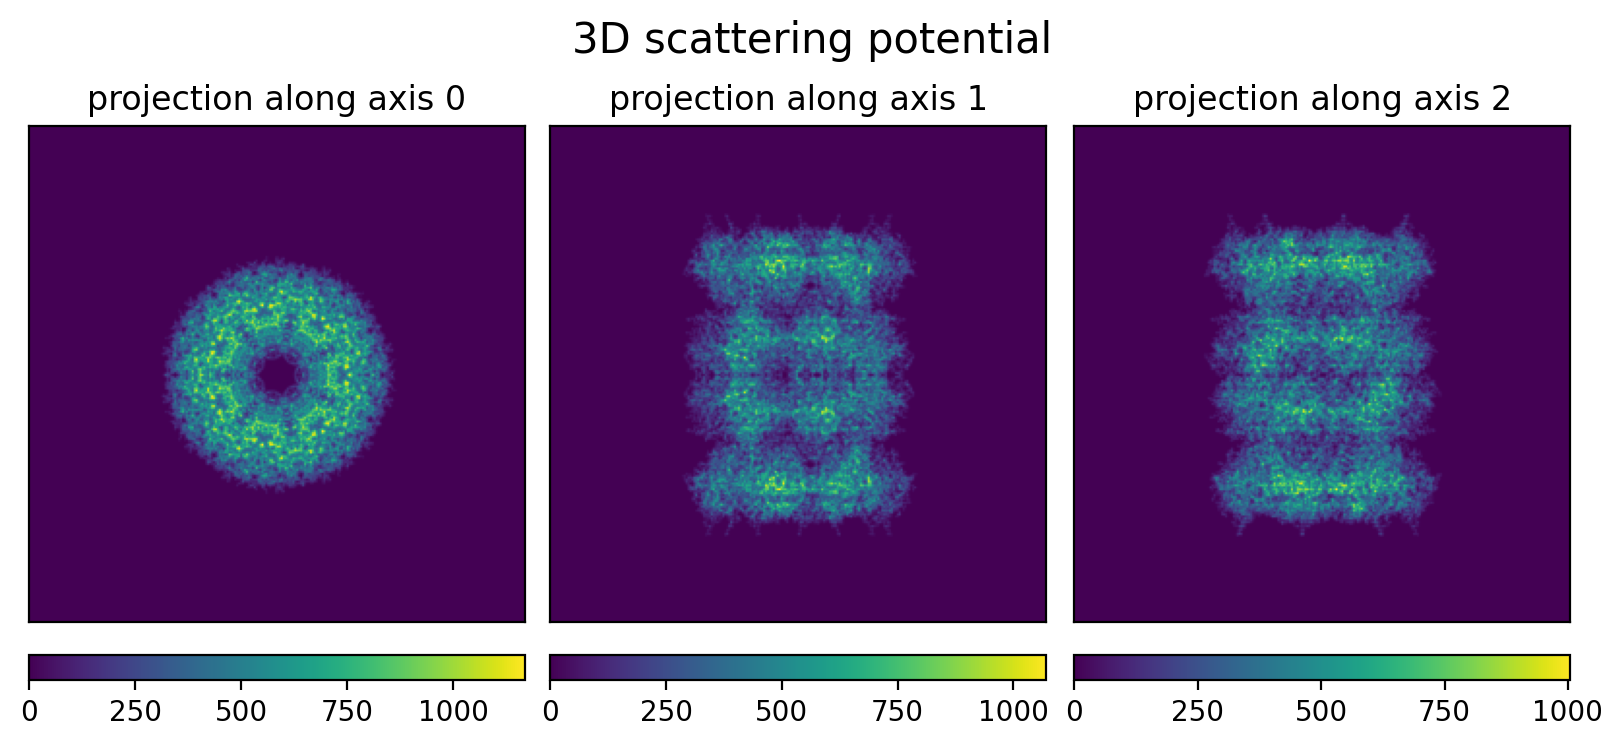

In [4]:
plot3d(V, title="3D scattering potential")

## Generate dataset
Here, you can choose to either use random or in-plane rotations, and random or fixed defocus values (comment/uncomment respectively).

In [5]:
n_particles = 3000
energy = 300  # keV
dose_per_angstrom = 20  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1

In [6]:
# random quaternions
quaternions = rotations.random_quaternion(n_particles)

# in-plane rotations (around z-axis)
# angles = torch.linspace(0, 360, n_particles + 1)
# angles = angles[:-1] / 180 * torch.pi
# quaternions = []
# for a in angles:
#     # (x,y,z,w)
#     quaternions.append(torch.tensor([0, 0, torch.sin(a / 2), torch.cos(a / 2)]))
# quaternions = torch.stack(quaternions)

quaternions.shape

torch.Size([3000, 4])

In [7]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 15000  # angstrom
dfang = 0
defocus_A = torch.rand(n_particles) * (defocus_max - defocus_min) + defocus_min

# fixed defocus
# defocus_A = 10000 * torch.ones(n_particles)

# beamtilt
tiltx = 0.0
tilty = 0.0

# phaseshift
phaseshift = 0

# trefoil
tref1 = 0
tref2 = 0
# [Cs, dfu, dfv, dfang, tiltx, tilty, phaseshift, tref1, tref2]
ctf_params = torch.stack(
    [
        torch.tensor([Cs, d, d, dfang, tiltx, tilty, phaseshift, tref1, tref2])
        for d in defocus_A
    ]
)
ctf_params.shape

torch.Size([3000, 9])

In [8]:
# random shift. set to 0 for no shifts
shift = 2  # A
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([3000, 2])

In [9]:
# save parameters
torch.save(quaternions, '../cache/quaternions.py')
torch.save(translations, '../cache/translations.py')
torch.save(ctf_params, '../cache/ctf_params.py')
torch.save(V, '../cache/V.py')

In [10]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'

noise_model = "poisson"  # 'poisson' or None
# noise_model = None

ice_model = "iterative"  # 'randomchoice' for fast & inaccurate, 'iterative' for slow & accurate, or None
# ice_model = None

ice_thickness = 0  # angstroms, set to 0 for minimum ice thickness = particle box size

crowd_min_distance = pm.max_diameter * 0.9  # angstroms, set to None for no crowding
# crowd_min_distance = None

# pad_fft = False # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = 'True'

In [ ]:
output_path = "../cache/images.pt"
cmd = [
    "python",
    "../src/cryosim/simulate_particles.py",
    "--V_path", '../cache/V.py',
    "--dx", f"{dx}",
    "--quaternions_path", '../cache/quaternions.py',
    "--translations_path", '../cache/translations.py',
    "--ctf_params_path", '../cache/ctf_params.py',
    "--energy", f"{energy}",
    "--dose_per_angstrom", f"{dose_per_angstrom}",
    "--n_particles", f"{n_particles}",
    "--batch_size", "5",
    "--scattering_model", scattering_model,
    "--aberration_model", aberration_model,
    "--noise_model", noise_model,
    "--ice_model", ice_model,
    "--ice_thickness", f'{ice_thickness}',
    "--alpha", f'{alpha}',
    "--crowd_min_distance", f'{crowd_min_distance}',
    "--pad_fft", pad_fft,
    "--devices", "0,1,2", #cuda ids
    "--output_path", output_path,
]



process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1  # line-buffered
)

# Print output in real time, preserving \r
while True:
    output = process.stdout.read(1)  # read one character at a time
    if output == '' and process.poll() is not None:
        break
    if output:
        sys.stdout.write(output)
        sys.stdout.flush()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA L40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/3
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/3
Initializing distributed: GLOBAL_RANK: 2, MEMBER: 3/3
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 3 processes
----------------------------------------------------------------------------------------------------

LOCAL_RANK: 1 - CUDA_VISIBLE_DEVICE

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



sing a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  self.dfv[idx],
/mnt/cbis/home/e0788253/czii/cryosim/src/cryosim/imagegenerator.py:293: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  self.dfang[idx],
/mnt/cbis/home/e0788253/czii/cryosim/src/cryosim/imagegenerator.py:294: UserWarning: Using a non-tuple sequence for multidimensional index

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)





Computing batches of icecubes:   0%|          | 0/5 [00:00<?, ?it/s]
                                                                    

Computing batches of icecubes:   0%|          | 0/5 [00:00<?, ?it/s]

                                                                    
Computing batches of icecubes:   0%|          | 0/5 [00:00<?, ?it/s]
                                                                    
Complex propagator

Multislicing:   0%|          | 0/256 [00:00<?, ?it/s]
                                                     
Complex propagator


Multislicing:   0%|          | 0/256 [00:00<?, ?it/s]

                                                     
Predicting DataLoader 0:   2%|▏         | 3/200 [00:12<13:30,  0.24it/s]Complex propagator

Multislicing:   0%|          | 0/256 [00:00<?, ?it/s]
                                                     

Computing batches of icecubes:   0%|          | 0/5 [00:00<?, ?it/s]
                                                      

In [ ]:
output_dir = os.path.dirname(output_path)

## Clean up data
# find all predictions and batch index files
prediction_files = sorted(glob.glob(os.path.join(output_dir, "predictions_*.pt")))
index_files = sorted(glob.glob(os.path.join(output_dir, "batch_indices_*.pt")))

all_preds = []
all_indices = []

for p_file, i_file in zip(prediction_files, index_files):
    preds = torch.load(p_file)      # [batch_size, H, W] or similar
    indices = torch.load(i_file)    # [batch_size]
    all_preds.append(preds)
    all_indices.append(indices)

# concatenate all predictions and indices
all_preds = torch.cat(all_preds, dim=0)
all_indices = torch.cat(all_indices, dim=0)

# sort predictions according to original batch indices
sorted_order = torch.argsort(all_indices)
images = all_preds[sorted_order]

# save final ordered predictions
torch.save(images, output_path)
print(f"Saved all {images.shape[0]} images to images.pt")

# delete intermediate files
for f in prediction_files + index_files:
    os.remove(f)

In [ ]:
images.shape

In [ ]:
fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(images[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

In [ ]:
# normalize and flip sign
particles, means, stds = normalize_particles(images)
particles = -particles

fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(particles[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

In [ ]:
# change folder paths for your use.
# folderpath='/scratch/loh/joel/5MAC/simulated_data/'
# filename = '3000_256x256_20dose_nocrowd_and_ice_16sep2025'
# create_particle_starfile(
#     particles,
#     rotations=quaternions,
#     translations=translations,
#     ctf_params=ctf_params,
#     dx=dx,
#     energy=energy,
#     alpha=alpha,
#     starfilename=filename,
#     folderpath=folderpath
# )